In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = "Customer_Churn_Data_Large.xlsx"

demographics = pd.read_excel(file, sheet_name="Customer_Demographics")
transactions = pd.read_excel(file, sheet_name="Transaction_History")
service = pd.read_excel(file, sheet_name="Customer_Service")
online = pd.read_excel(file, sheet_name="Online_Activity")
churn = pd.read_excel(file, sheet_name="Churn_Status")

In [4]:
demographics.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [6]:
transactions.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [7]:
service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [8]:
online.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [9]:
churn.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [11]:
print(demographics.shape)
print(transactions.shape)
print(service.shape)
print(online.shape)
print(churn.shape)

(1000, 5)
(5054, 5)
(1002, 5)
(1000, 4)
(1000, 2)


In [12]:
transaction_features = transactions.groupby("CustomerID").agg(
    total_transactions=("TransactionID", "count"),
    total_spent=("AmountSpent", "sum")
).reset_index()

transaction_features.head()

,CustomerID,total_transactions,total_spent
0,1,1,416.50
1,2,7,1547.42
2,3,6,1702.98
3,4,5,917.29
4,5,8,2001.49


In [14]:
service_features = service.groupby("CustomerID").agg(
    total_interactions=("InteractionID", "count")
).reset_index()

service_features.head()

,CustomerID,total_interactions
0,1,1
1,2,1
2,3,1
3,4,2
4,6,1


In [16]:
df = demographics.merge(transaction_features, on="CustomerID", how="left")
df = df.merge(service_features, on="CustomerID", how="left")
df = df.merge(online, on="CustomerID", how="left")
df = df.merge(churn, on="CustomerID", how="left")

df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,total_transactions,total_spent,total_interactions,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,1,416.50,1.0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7,1547.42,1.0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,6,1702.98,1.0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,5,917.29,2.0,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,8,2001.49,NaN,2023-10-27,41,Website,0


In [17]:
df.isnull().sum()

CustomerID              0
Age                     0
Gender                  0
MaritalStatus           0
IncomeLevel             0
total_transactions      0
total_spent             0
total_interactions    332
LastLoginDate           0
LoginFrequency          0
ServiceUsage            0
ChurnStatus             0
dtype: int64

In [18]:
df = df.fillna(0)

In [19]:
df["ChurnStatus"].value_counts()

ChurnStatus
0    796
1    204
Name: count, dtype: int64

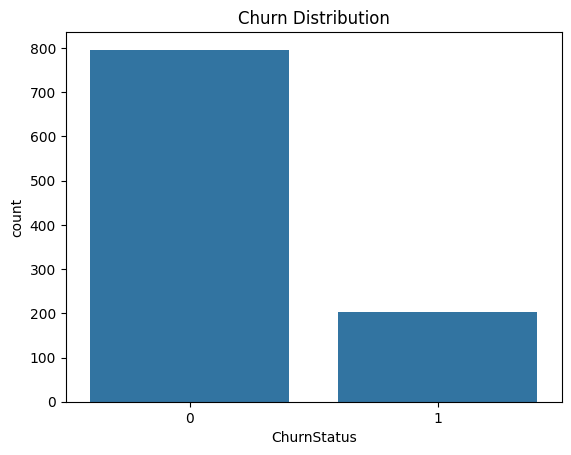

In [20]:
sns.countplot(x="ChurnStatus", data=df)
plt.title("Churn Distribution")
plt.show()

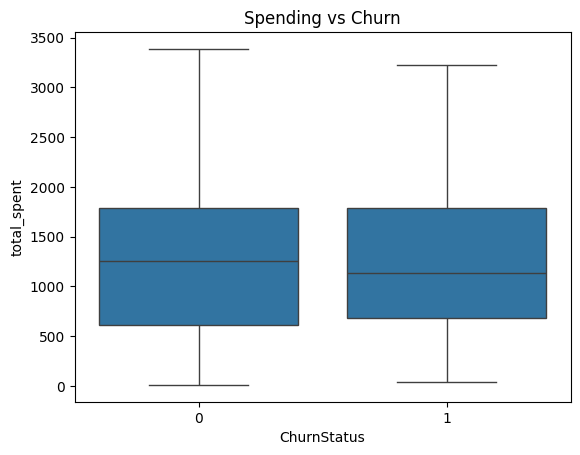

In [21]:
sns.boxplot(x="ChurnStatus", y="total_spent", data=df)
plt.title("Spending vs Churn")
plt.show()

In [22]:
df.to_csv("cleaned_customer_churn_dataset.csv", index=False)

In [ ]:
# Task 2
# Building a machine learning model

In [25]:
import pandas as pd

df = pd.read_csv("cleaned_customer_churn_dataset.csv")
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,total_transactions,total_spent,total_interactions,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,1,416.50,1.0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7,1547.42,1.0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,6,1702.98,1.0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,5,917.29,2.0,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,8,2001.49,0.0,2023-10-27,41,Website,0


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Convert target if needed
if df["ChurnStatus"].dtype == "object":
    df["ChurnStatus"] = df["ChurnStatus"].map({"No": 0, "Yes": 1})

# Drop raw date columns
date_cols = ["TransactionDate", "InteractionDate", "LastLoginDate",
             "last_transaction_date", "last_interaction_date"]
df = df.drop(columns=date_cols, errors="ignore")

# Find all categorical columns except target
categorical_cols = df.select_dtypes(include="object").columns.tolist()
if "ChurnStatus" in categorical_cols:
    categorical_cols.remove("ChurnStatus")

# Encode all categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define X and y
X = df_encoded.drop("ChurnStatus", axis=1)
y = df_encoded["ChurnStatus"]

# Check remaining non-numeric columns
print("Remaining non-numeric columns:")
print(X.select_dtypes(exclude=["int64", "float64", "uint8", "bool"]).columns)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

print("Model trained successfully")

Remaining non-numeric columns:
Index([], dtype='object')
Model trained successfully


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.5
Precision: 0.1958762886597938
Recall: 0.4634146341463415
F1 Score: 0.2753623188405797
ROC-AUC: 0.49992330111980365

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.51      0.62       159
           1       0.20      0.46      0.28        41

    accuracy                           0.50       200
   macro avg       0.49      0.49      0.45       200
weighted avg       0.67      0.50      0.55       200


Confusion Matrix:

[[81 78]
 [22 19]]


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.795
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.44278263537352347


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
3,total_spent,0.171506
0,CustomerID,0.170051
5,LoginFrequency,0.161547
1,Age,0.155350
2,total_transactions,0.090221
4,total_interactions,0.050908
6,Gender_M,0.031709
12,ServiceUsage_Online Banking,0.029502
11,IncomeLevel_Medium,0.025579
10,IncomeLevel_Low,0.024787


In [43]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.500,0.195876,0.463415,0.275362,0.499923
1,Random Forest,0.795,0.000000,0.000000,0.000000,0.442783


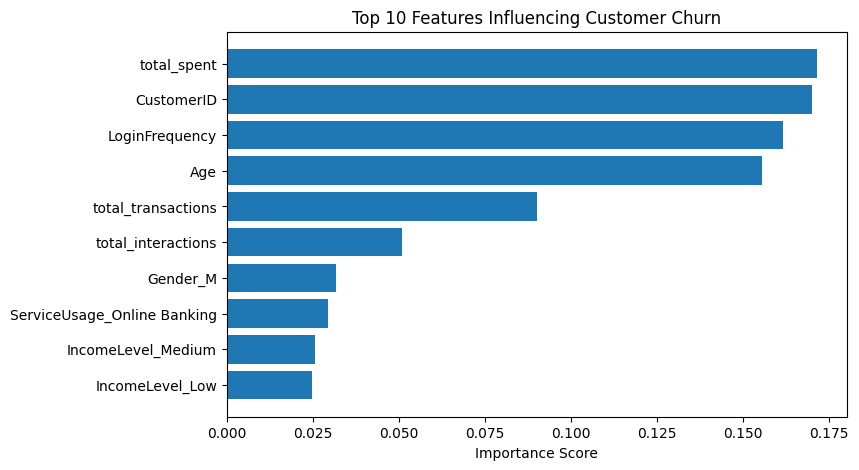

In [44]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Importance Score")
plt.show()

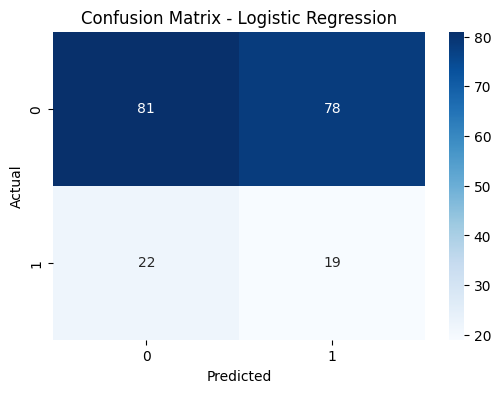

In [45]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

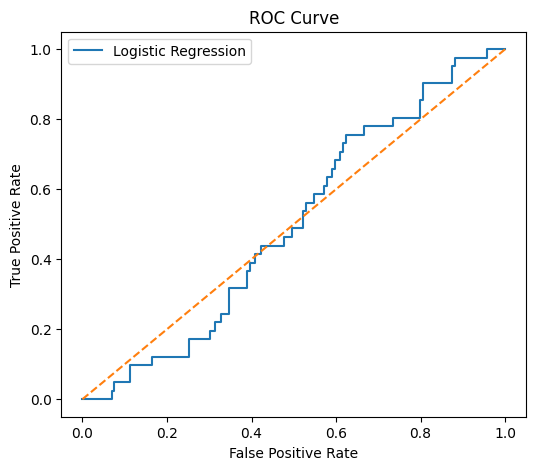

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()